# 02b CORE5 Model Comparison

Aim of this notebook: compare the five static NHS scoring methods on the calibration partition and select the primary scorer.

All scorer parameters are estimated using fitting accounts only. Calibration window 0 is used for proxy-group separation and upper-tail retrieval; calibration windows 1–3 are used for cross-window ranking stability. The test partition is not evaluated here.


## 0. Configuration


In [1]:
from pathlib import Path
import hashlib
import importlib
import json
import pickle

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score, roc_auc_score

import nhs_split_eval as se


FEATURE_PATH = Path("static_features_v2/feat_final.parquet")
FEATURE_META_PATH = Path("static_features_v2/feature_build_meta.json")
ACCOUNT_SPLIT_PATH = Path("account_split_static.json")
REPRESENTATION_META_PATH = Path(
    "eda_outputs_01b_fit_features_core5/representation_meta.json"
)

MIXTURE_STATE_PATH = Path(
    "custom_mixture_development/custom_mixture_K6_state.json"
)
MIXTURE_META_PATH = Path(
    "custom_mixture_development/mixture_development_meta.json"
)

OUT = Path("static_model_comparison")
OUT.mkdir(exist_ok=True)

CAL_METRICS_PATH = OUT / "calibration_model_metrics.csv"
CAL_STABILITY_PATH = OUT / "calibration_score_stability.csv"
SCORERS_PATH = OUT / "frozen_generic_scorers.pkl"
META_PATH = OUT / "model_comparison_meta.json"

TABLE2_PATH = OUT / "Table_02_calibration_model_comparison.csv"
FIGURE2_PATH = OUT / "Figure_02_precision_at_k.png"
TABLE8_PATH = OUT / "Table_08_calibration_topk.csv"

SEED = 42
STATIC_EVAL_WIN = 0
KS = (10, 30, 50, 100)

CORE5 = [
    "period_strength",
    "iat_cv",
    "log_volume",
    "log_fanout",
    "quiet_frac",
]

PRIMARY_METHOD = "kmeans_core5"

print("Configuration ready.")


Configuration ready.


## 1. Load frozen inputs

Load the canonical feature table, fitting/calibration account split, frozen CORE5 representation and the custom-mixture state produced in notebook 02a.


In [2]:
def file_sha256(path):
    path = Path(path)
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


for required in [
    FEATURE_PATH,
    FEATURE_META_PATH,
    ACCOUNT_SPLIT_PATH,
    REPRESENTATION_META_PATH,
    MIXTURE_STATE_PATH,
    MIXTURE_META_PATH,
]:
    if not required.exists():
        raise FileNotFoundError(f"Missing required input: {required}")

feature_meta = json.loads(FEATURE_META_PATH.read_text())
representation_meta = json.loads(REPRESENTATION_META_PATH.read_text())
split_obj = json.loads(ACCOUNT_SPLIT_PATH.read_text())
mixture_state = json.loads(MIXTURE_STATE_PATH.read_text())

actual_hash = file_sha256(FEATURE_PATH)
if feature_meta["output_hashes"]["feat_final"] != actual_hash:
    raise RuntimeError("Canonical feature table does not match notebook-01 provenance.")

if representation_meta["representation_name"] != "CORE5":
    raise RuntimeError("Notebook 01b does not declare CORE5.")

if representation_meta["core5_generic"] != CORE5:
    raise RuntimeError("CORE5 mismatch between notebooks 01b and 02b.")

fit_a = set(map(str, split_obj["fit"]))
cal_a = set(map(str, split_obj["calibration"]))

con = duckdb.connect()
feat = con.execute(
    f"SELECT * FROM '{FEATURE_PATH.as_posix()}'"
).df()
con.close()

feat["u"] = feat["u"].astype(str)

fit_df = feat.loc[feat["u"].isin(fit_a)].reset_index(drop=True)
cal_df = feat.loc[feat["u"].isin(cal_a)].reset_index(drop=True)

print(f"Fit rows / accounts       : {len(fit_df):,} / {len(fit_a):,}")
print(f"Calibration rows/accounts : {len(cal_df):,} / {len(cal_a):,}")


Fit rows / accounts       : 62,310 / 17,734
Calibration rows/accounts : 15,722 / 4,433


## 2. Fit the generic scorers

The empirical-rank baseline, K-means and GMM use the same oriented and standardised CORE5 information. The periodicity reference uses `period_strength` alone. The custom mixture uses the frozen six-component state from notebook 02a.

PCA is not part of the final dissertation comparison and is omitted.


In [3]:
generic_scorers = {
    "empirical_rank": se.FrozenBaseline(CORE5).fit(fit_df),
    "kmeans_core5": se.FrozenKMeans(
        CORE5,
        n_clusters=2,
        seed=SEED,
    ).fit(fit_df),
    "gmm_core5": se.FrozenGMM(
        CORE5,
        n_components=2,
        seed=SEED,
    ).fit(fit_df),
}

periodicity_fit_median = float(
    fit_df["period_strength"].median()
)

mix = importlib.import_module("nhs_mixture")

state_version = mixture_state.get(
    "mixture_model_version",
    mix.MIXTURE_MODEL_VERSION,
)
if state_version != mix.MIXTURE_MODEL_VERSION:
    raise RuntimeError(
        "Frozen custom-mixture state uses a different model implementation."
    )

mixture_params = mixture_state["params"]
mixture_machine_comps = [
    int(x) for x in mixture_state["machine_comps"]
]

print("Fitted generic scorers:")
for name in generic_scorers:
    print(" -", name)
print("Loaded frozen custom mixture.")


Fitted generic scorers:
 - empirical_rank
 - kmeans_core5
 - gmm_core5
Loaded frozen custom mixture.


## 3. Calibration window-0 evaluation

Evaluation uses the automation-associated reference group: dollar-suffix computer accounts together with `SYSTEM`, `LOCAL SERVICE` and `NETWORK SERVICE`. U-named accounts form the comparison group, while `ANONYMOUS LOGON` is excluded from the positive reference.

AP and AUROC are calculated on the two reference groups. P@K and R@K use the same positive reference over the complete calibration ranking.


In [4]:
def evaluate_scores(df_with_labels, scores, ks=KS):
    scores = np.asarray(scores, dtype=float)

    reference = df_with_labels["is_anchor"].to_numpy(dtype=bool)
    human = df_with_labels["kind"].eq("human").to_numpy()
    eval_mask = reference | human

    out = {
        "reference_prevalence": float(reference[eval_mask].mean()),
    }

    out["AUPRC"] = float(
        average_precision_score(
            reference[eval_mask],
            scores[eval_mask],
        )
    )
    out["ROC_AUC"] = float(
        roc_auc_score(
            reference[eval_mask],
            scores[eval_mask],
        )
    )

    for k in ks:
        out[f"P@{k}"] = se.precision_at_k(scores, reference, k)
        out[f"R@{k}"] = se.recall_at_k(scores, reference, k)

    return out


cal_labeled = se.add_labels(cal_df)
cal_w0 = (
    cal_labeled.loc[cal_labeled["win"] == STATIC_EVAL_WIN]
    .reset_index(drop=True)
)

rows = []

rows.append({
    "method": "periodicity_reference",
    **evaluate_scores(
        cal_w0,
        cal_w0["period_strength"]
        .fillna(periodicity_fit_median)
        .to_numpy(),
    ),
})

rows.append({
    "method": "empirical_rank",
    **evaluate_scores(
        cal_w0,
        generic_scorers["empirical_rank"].score(cal_w0),
    ),
})

rows.append({
    "method": "kmeans_core5",
    **evaluate_scores(
        cal_w0,
        generic_scorers["kmeans_core5"].score(cal_w0),
    ),
})

rows.append({
    "method": "gmm_core5",
    **evaluate_scores(
        cal_w0,
        generic_scorers["gmm_core5"].score(cal_w0),
    ),
})

rows.append({
    "method": "custom_mixture",
    **evaluate_scores(
        cal_w0,
        mix.score_mixture_k(
            cal_w0,
            mixture_params,
            mixture_machine_comps,
        ),
    ),
})

cal_metrics = pd.DataFrame(rows)
cal_metrics.to_csv(CAL_METRICS_PATH, index=False)

print(
    cal_metrics[
        [
            "method",
            "AUPRC",
            "ROC_AUC",
            "P@10",
            "P@30",
            "P@50",
            "P@100",
        ]
    ]
    .round(3)
    .to_string(index=False)
)


               method  AUPRC  ROC_AUC  P@10  P@30  P@50  P@100
periodicity_reference  0.842    0.724   0.8 0.867  0.88   0.92
       empirical_rank  0.834    0.699   0.9 0.900  0.94   0.96
         kmeans_core5  0.853    0.746   1.0 1.000  0.98   0.94
            gmm_core5  0.830    0.705   0.9 0.800  0.86   0.88
       custom_mixture  0.849    0.734   0.9 0.900  0.90   0.94


## 4. Cross-window ranking stability

For each scorer, compare calibration window 0 with windows 1–3 using accounts observed in both windows. The median Spearman correlation summarises ranking stability.


In [5]:
score_functions = {
    "periodicity_reference": lambda d: (
        d["period_strength"]
        .fillna(periodicity_fit_median)
        .to_numpy()
    ),
    "empirical_rank": generic_scorers["empirical_rank"].score,
    "kmeans_core5": generic_scorers["kmeans_core5"].score,
    "gmm_core5": generic_scorers["gmm_core5"].score,
    "custom_mixture": lambda d: mix.score_mixture_k(
        d,
        mixture_params,
        mixture_machine_comps,
    ),
}

stability_rows = []

for method, score_fn in score_functions.items():
    tmp = cal_df[["u", "win"]].copy()
    tmp["score"] = score_fn(cal_df)

    s0 = (
        tmp.loc[tmp["win"] == 0, ["u", "score"]]
        .rename(columns={"score": "score_w0"})
    )

    for w in [1, 2, 3]:
        sw = (
            tmp.loc[tmp["win"] == w, ["u", "score"]]
            .rename(columns={"score": "score_w"})
        )
        merged = s0.merge(sw, on="u")

        stability_rows.append({
            "method": method,
            "comparison": f"w0_vs_w{w}",
            "n_accounts": len(merged),
            "spearman": float(
                merged["score_w0"].corr(
                    merged["score_w"],
                    method="spearman",
                )
            ),
        })

cal_stability = pd.DataFrame(stability_rows)
cal_stability.to_csv(CAL_STABILITY_PATH, index=False)

print(cal_stability.round(3).to_string(index=False))
print("\nMedian stability:")
print(
    cal_stability
    .groupby("method")["spearman"]
    .median()
    .sort_values(ascending=False)
    .round(3)
    .to_string()
)


               method comparison  n_accounts  spearman
periodicity_reference   w0_vs_w1        3678     0.825
periodicity_reference   w0_vs_w2        3634     0.507
periodicity_reference   w0_vs_w3        3583     0.484
       empirical_rank   w0_vs_w1        3678     0.852
       empirical_rank   w0_vs_w2        3634     0.736
       empirical_rank   w0_vs_w3        3583     0.680
         kmeans_core5   w0_vs_w1        3678     0.852
         kmeans_core5   w0_vs_w2        3634     0.765
         kmeans_core5   w0_vs_w3        3583     0.734
            gmm_core5   w0_vs_w1        3678     0.865
            gmm_core5   w0_vs_w2        3634     0.564
            gmm_core5   w0_vs_w3        3583     0.531
       custom_mixture   w0_vs_w1        3678     0.846
       custom_mixture   w0_vs_w2        3634     0.734
       custom_mixture   w0_vs_w3        3583     0.709

Median stability:
method
kmeans_core5             0.765
empirical_rank           0.736
custom_mixture           0.734
g

## 5. Dissertation outputs and scorer selection

Table 2 combines calibration AP, AUROC and median cross-window stability. Figure 2 shows P@K for the automation-associated reference group. Supplementary Table 8 contains the complete P@K and R@K results.

K-means is selected as the primary NHS because it gives the strongest overall balance of proxy separation, short-list precision, cross-window stability and interpretability.


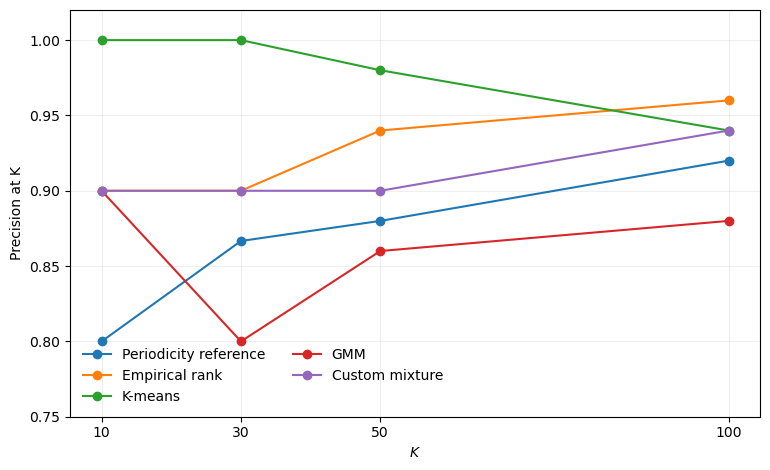

In [6]:
METHOD_DISPLAY = {
    "periodicity_reference": "Periodicity reference",
    "empirical_rank": "Empirical rank",
    "kmeans_core5": "K-means",
    "gmm_core5": "GMM",
    "custom_mixture": "Custom mixture",
}

median_stability = (
    cal_stability
    .groupby("method", as_index=False)["spearman"]
    .median()
    .rename(columns={"spearman": "median_cross_window_rho"})
)

table2 = (
    cal_metrics[
        ["method", "AUPRC", "ROC_AUC"]
    ]
    .merge(median_stability, on="method")
)

table2["Method"] = table2["method"].map(METHOD_DISPLAY)
table2 = table2[
    ["Method", "AUPRC", "ROC_AUC", "median_cross_window_rho"]
]
table2.to_csv(TABLE2_PATH, index=False)

topk_cols = ["method"]
for k in KS:
    topk_cols += [f"P@{k}", f"R@{k}"]

table8 = cal_metrics[topk_cols].copy()
table8["Method"] = table8["method"].map(METHOD_DISPLAY)
table8 = table8.drop(columns="method")
table8.to_csv(TABLE8_PATH, index=False)


fig, ax = plt.subplots(figsize=(7.8, 4.8))

for _, row in cal_metrics.iterrows():
    ax.plot(
        KS,
        [row[f"P@{k}"] for k in KS],
        marker="o",
        label=METHOD_DISPLAY[row["method"]],
    )

ax.set_xlabel(r"$K$")
ax.set_ylabel("Precision at K")
ax.set_xticks(KS)

# Match the figure used in the dissertation.
ax.set_ylim(0.75, 1.02)
ax.set_yticks(np.arange(0.75, 1.01, 0.05))
ax.grid(True, alpha=0.2)

ax.legend(
    frameon=False,
    ncol=2,
    loc="lower left",
)

fig.tight_layout()
fig.savefig(
    FIGURE2_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 6. Save frozen scorer state


In [7]:
scorer_bundle = {
    "scorers": generic_scorers,
    "periodicity_fit_median": periodicity_fit_median,
    "fit_accounts": fit_a,
    "calibration_accounts": cal_a,
    "core5": CORE5,
    "feature_sha256": actual_hash,
    "primary_method": PRIMARY_METHOD,
}

with open(SCORERS_PATH, "wb") as f:
    pickle.dump(scorer_bundle, f)

comparison_meta = {
    "pipeline_stage": "02b_core5_model_comparison",
    "primary_method": PRIMARY_METHOD,
    "candidate_methods": list(METHOD_DISPLAY),
    "core5": CORE5,
    "feature_sha256": actual_hash,
    "account_split_sha256": file_sha256(ACCOUNT_SPLIT_PATH),
    "representation_meta_sha256": file_sha256(REPRESENTATION_META_PATH),
    "mixture_state_sha256": file_sha256(MIXTURE_STATE_PATH),
    "evaluation_positive_reference": "dollar_suffix_plus_SYSTEM_LOCAL_SERVICE_NETWORK_SERVICE",
    "evaluation_negative_reference": "U_named_user_proxy",
    "anonymous_logon_in_positive_reference": False,
    "test_evaluated": False,
    "outputs": {
        "calibration_metrics": str(CAL_METRICS_PATH),
        "calibration_stability": str(CAL_STABILITY_PATH),
        "frozen_scorers": str(SCORERS_PATH),
        "table_2": str(TABLE2_PATH),
        "figure_2": str(FIGURE2_PATH),
        "table_8": str(TABLE8_PATH),
    },
}

META_PATH.write_text(json.dumps(comparison_meta, indent=2))

print("Model comparison complete.")
print("Primary scorer:", PRIMARY_METHOD)
print("Test evaluated: False")


Model comparison complete.
Primary scorer: kmeans_core5
Test evaluated: False
